## 80-20 Test Split by Person

Split the data by person: using andrew and divit as test data.

In [4]:
import os
import glob
import shutil

# Your defined actions
actions = [
    "idle", "jab", "cross", "lead_hook", "rear_hook", "uppercut", 
    "jumping_cross", "rear_low_kick", "side_kick", "spinning_back_high_kick", 
    "crouching_low_sweep", "grab", "hadouken", "shoryuken"
]

# The people who should be isolated in the test set
test_subjects = ["divit", "andrew"]

# Authors to completely exclude from both train and test sets
exclude_authors = ["kevin", "parnika", "agni", "alfred"] 

# Input directory
data_dir = "Phase2/instance_clips"

# Output directories
train_dir = "Train_Test_Data/Seperated_By_Person/Clips_Split_80_20/Train"
test_dir = "Train_Test_Data/Seperated_By_Person/Clips_Split_80_20/Test"

# Create the output directories if they don't already exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

all_files = glob.glob(os.path.join(data_dir, "*.csv"))

train_files = []
test_files = []
excluded_files = []

for file_path in all_files:
    filename = os.path.basename(file_path).lower()
    
    # 1. Check if the file belongs to an excluded author
    is_excluded = any(f"_{author}" in filename for author in exclude_authors)
    if is_excluded:
        excluded_files.append(file_path)
        continue  # Skip the rest of the loop for this file
    
    # 2. Check if the file belongs to the test subjects
    is_test_subject = any(f"_{subject}" in filename for subject in test_subjects)
    
    # 3. Assign to list and copy to respective folder
    if is_test_subject:
        test_files.append(file_path)
        shutil.copy(file_path, os.path.join(test_dir, os.path.basename(file_path)))
    else:
        train_files.append(file_path)
        shutil.copy(file_path, os.path.join(train_dir, os.path.basename(file_path)))

print(f"Total files found: {len(all_files)}")
print(f"Total Excluded files skipped: {len(excluded_files)}")
print(f"Total Train files copied: {len(train_files)}")
print(f"Total Test files copied: {len(test_files)}")
print("\nSuccess! Files have been distributed to your Train and Test folders (with excluded authors skipped).")

Total files found: 853
Total Excluded files skipped: 50
Total Train files copied: 631
Total Test files copied: 172

Success! Files have been distributed to your Train and Test folders (with excluded authors skipped).


## EDA

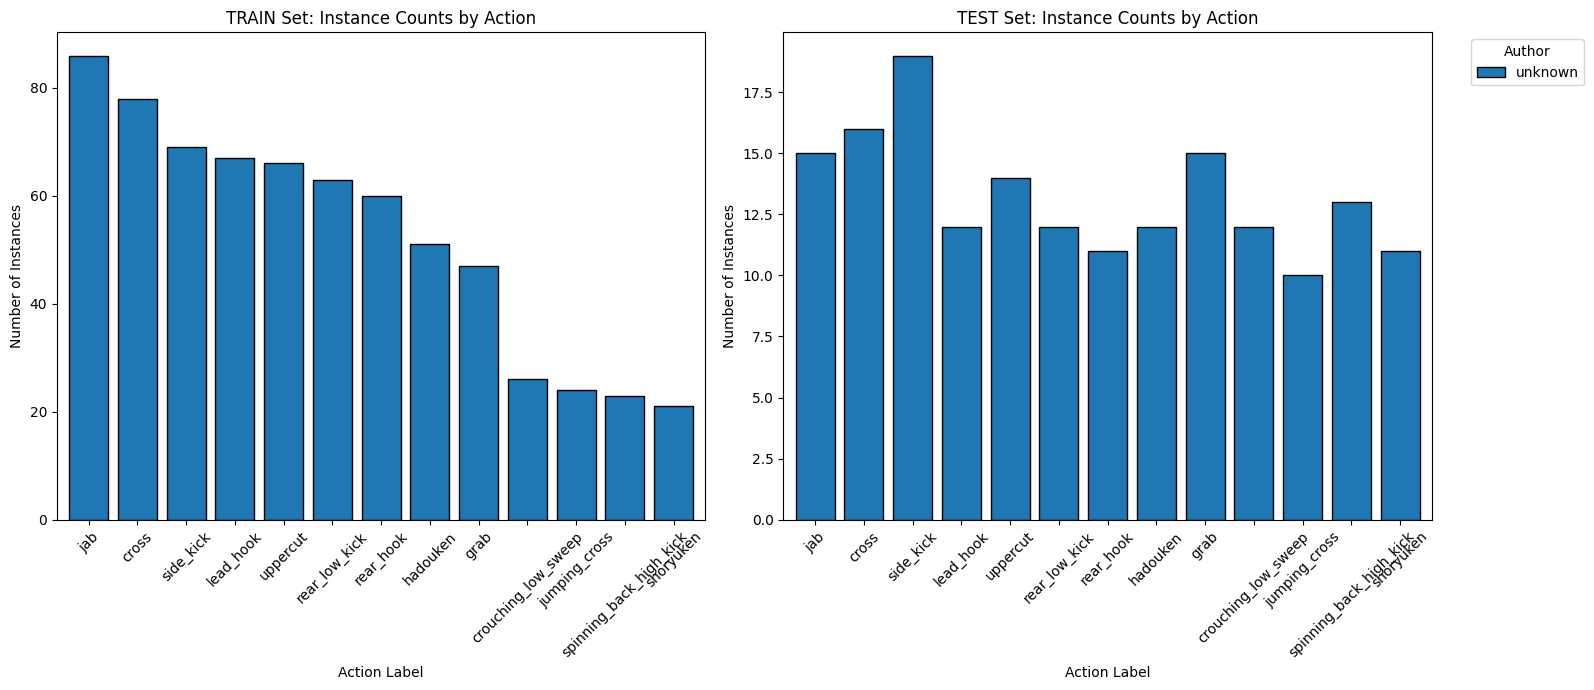

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Note: I am using 'filtered_instances' and the column 'label' to match 
# the previous processing step. If you specifically named your dataframe 
# 'split_df' and the column 'action', you can easily swap those terms back in!

# 1. Filter out 'idle' actions
df_filtered = filtered_instances[filtered_instances['label'] != 'idle'].copy()

if not df_filtered.empty:
    
    # 2. Setup consistent colors across both plots
    unique_authors = sorted(df_filtered['author'].unique())
    
    # Using the updated Matplotlib method to get colormaps
    cmap = plt.colormaps.get_cmap('tab20')
    color_list = [cmap(i / len(unique_authors)) for i in range(len(unique_authors))]

    # Initialize a 1x2 Figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # --- Plot 1: TRAIN SET ---
    train_df = df_filtered[df_filtered['split'] == 'Train']
    
    if not train_df.empty:
        pivot_train = pd.crosstab(train_df['label'], train_df['author'])
        
        # Force all authors to be columns to keep colors aligned perfectly
        pivot_train = pivot_train.reindex(columns=unique_authors, fill_value=0)
        
        # Sort actions by total frequency descending
        pivot_train = pivot_train.loc[pivot_train.sum(axis=1).sort_values(ascending=False).index]
        
        pivot_train.plot(kind='bar', stacked=True, ax=ax1, color=color_list, edgecolor='black', width=0.8)
        ax1.set_title('TRAIN Set: Instance Counts by Action')
        ax1.set_ylabel('Number of Instances')
        ax1.set_xlabel('Action Label')
        ax1.tick_params(axis='x', rotation=45)
        
        # Remove legend here to prevent double-clutter
        if ax1.get_legend():
            ax1.get_legend().remove() 
    else:
        ax1.set_title('TRAIN Set: No Data')

    # --- Plot 2: TEST SET ---
    test_df = df_filtered[df_filtered['split'] == 'Test']
    
    if not test_df.empty:
        pivot_test = pd.crosstab(test_df['label'], test_df['author'])
        
        # Force all authors to be columns to keep colors aligned
        pivot_test = pivot_test.reindex(columns=unique_authors, fill_value=0)
        
        # Sort Test data using the EXACT same action order as Train for an easy 1:1 comparison
        if not train_df.empty:
            ordered_actions = [idx for idx in pivot_train.index if idx in pivot_test.index]
            missing_in_train = [idx for idx in pivot_test.index if idx not in pivot_train.index] 
            pivot_test = pivot_test.loc[ordered_actions + missing_in_train]

        pivot_test.plot(kind='bar', stacked=True, ax=ax2, color=color_list, edgecolor='black', width=0.8)
        ax2.set_title('TEST Set: Instance Counts by Action')
        ax2.set_ylabel('Number of Instances')
        ax2.set_xlabel('Action Label')
        ax2.tick_params(axis='x', rotation=45)
        
        # Put the master legend on the far right
        ax2.legend(title='Author', bbox_to_anchor=(1.05, 1), loc='upper left') 
    else:
        ax2.set_title('TEST Set: No Data')

    plt.tight_layout()
    plt.show()

else:
    print("No non-idle data available to plot.")